In [ ]:
babies<-read.csv("/content/babies.csv", header=TRUE, sep = ";")
head(babies)

,bwt,gestation,parity,age,height,weight,smoke
,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,120,284,0,27,62,100,0
2,113,282,0,33,64,135,0
3,128,279,0,28,64,115,1
4,123,999,0,36,69,190,0
5,108,282,0,23,67,125,1
6,136,286,0,25,62,93,0


`babies4cov <- subset(babies, select = -c(parity, smoke))`: Esta línea crea un nuevo conjunto de datos llamado `babies4cov` utilizando la función `subset()` en el conjunto de datos original `babies`. El argumento `select = -c(parity, smoke)` indica que se deben seleccionar todas las columnas del conjunto de datos original excepto las columnas `parity` y `smoke`. La función `c()` se utiliza para concatenar los nombres de las columnas que se desean excluir, y el operador `-` delante de `c(parity, smoke)` indica que se deben excluir estas columnas.

In [ ]:
babies4cov<-subset(babies, select=-c(parity,smoke))
head(babies4cov)

,bwt,gestation,age,height,weight
,<int>,<int>,<int>,<int>,<int>
1,120,284,27,62,100
2,113,282,33,64,135
3,128,279,28,64,115
4,123,999,36,69,190
5,108,282,23,67,125
6,136,286,25,62,93


El comando `cov()` en R se utiliza para calcular la matriz de covarianza de un conjunto de datos. Sin embargo, ten en cuenta que la función `cov()` solo puede calcular la matriz de covarianza para variables numéricas en el conjunto de datos.

Dado que el conjunto de datos `babies4cov` se creó excluyendo las columnas `parity` y `smoke`, podemos asumir que contiene solo variables numéricas (ya que `parity` parece representar el número de hijos y `smoke` probablemente indica si la madre fuma o no, lo cual podrían ser variables categóricas).

Por lo tanto, si `babies4cov` contiene solo variables numéricas, puedes usar el comando `cov()` para calcular la matriz de covarianza de este conjunto de datos. Por ejemplo:

```R
cov_matrix <- cov(babies4cov)
```

Esto te proporcionará una matriz que contiene las covarianzas entre todas las variables numéricas en el conjunto de datos `babies4cov`.

**Covarianza:**
La covarianza es una medida de la relación lineal entre dos variables aleatorias. Indica cómo cambian juntas dos variables. Una covarianza positiva indica que las variables tienden a aumentar o disminuir juntas, mientras que una covarianza negativa indica que una variable tiende a aumentar mientras la otra tiende a disminuir. Sin embargo, la covarianza en sí misma no proporciona una medida estandarizada de la fuerza o dirección de la relación entre las variables.

In [ ]:
cov(babies4cov)

,bwt,gestation,age,height,weight
bwt,332.568177,85.667014,3.419612,12.04483,126.10747
gestation,85.667014,5648.555049,-1.584344,26.08937,549.66666
age,3.419612,-1.584344,41.692750,1.64819,59.89698
height,12.044825,26.089368,1.648190,27.67880,467.56067
weight,126.107473,549.666660,59.896979,467.56067,21866.28366


El comando `cor()` en R se utiliza para calcular la matriz de correlación entre las variables de un conjunto de datos. Esta matriz de correlación proporciona información sobre cómo están relacionadas linealmente las variables entre sí.

Dado que estás aplicando este comando al conjunto de datos `babies4cov`, que excluye las columnas `parity` y `smoke`, podemos asumir que contiene solo variables numéricas.

Por lo tanto, al ejecutar el comando `cor()` sobre `babies4cov`, obtendrás una matriz que muestra los coeficientes de correlación entre todas las variables numéricas en el conjunto de datos `babies4cov`. Este comando podría ser así:

```R
cor_matrix <- cor(babies4cov)
```

El objeto `cor_matrix` contendrá la matriz de correlación. Cada entrada de la matriz será el coeficiente de correlación entre dos variables: un valor cercano a 1 indicará una correlación positiva fuerte, un valor cercano a -1 indicará una correlación negativa fuerte, y un valor cercano a 0 indicará una correlación débil o nula.

**Correlación:**
La correlación es una medida estandarizada de la relación lineal entre dos variables aleatorias. Al igual que la covarianza, indica cómo cambian juntas dos variables, pero la correlación está limitada a valores entre -1 y 1. Una correlación de 1 indica una relación lineal positiva perfecta, una correlación de -1 indica una relación lineal negativa perfecta, y una correlación de 0 indica que no hay una relación lineal entre las variables.

En resumen, la covarianza proporciona información sobre la dirección de la relación entre dos variables, mientras que la correlación proporciona tanto la dirección como la fuerza de la relación, expresada en una escala estandarizada.

In [ ]:
cor(babies4cov)

,bwt,gestation,age,height,weight
bwt,1.00000000,0.062503538,0.029040643,0.12554127,0.04676414
gestation,0.06250354,1.000000000,-0.003264755,0.06598135,0.04945876
age,0.02904064,-0.003264755,1.000000000,0.04851805,0.06273172
height,0.12554127,0.065981354,0.048518050,1.00000000,0.60100328
weight,0.04676414,0.049458760,0.062731715,0.60100328,1.00000000


Cuando aplicas pairs(babies4cov), R generará una matriz de gráficos de dispersión donde cada celda de la matriz representa un gráfico de dispersión de una combinación única de dos variables en el conjunto de datos babies4cov. Esto te permite ver visualmente la relación entre todas las variables numéricas en babies4cov.

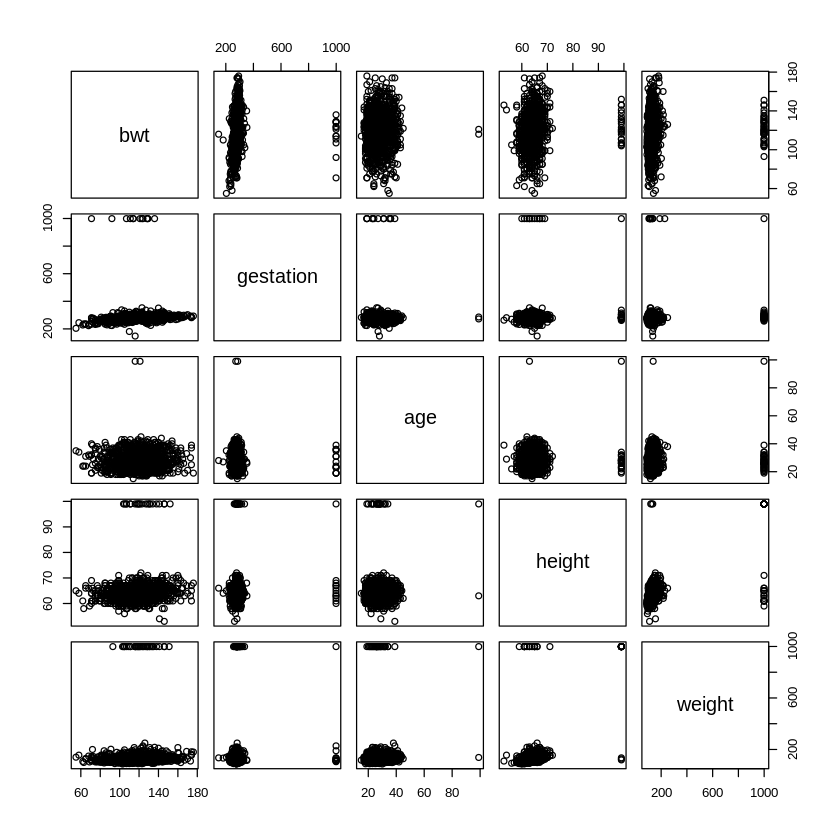

In [ ]:
pairs(babies4cov)

# **Limpieza de datos en el dataframe**

El siguiente código realiza varias operaciones en el conjunto de datos `babies4cov` para limpiar los datos y luego analizar la covarianza y la correlación, así como crear una matriz de gráficos de dispersión:

1. `babies4covclean <- babies4cov[(babies4cov$weight<999 & babies4cov$gestation<999 & babies4cov$height<99 & babies4cov$age< 99), ]`: Esta línea filtra el conjunto de datos `babies4cov` para eliminar las observaciones que tienen valores anómalos o incoherentes. Las condiciones `(babies4cov$weight<999 & babies4cov$gestation<999 & babies4cov$height<99 & babies4cov$age< 99)` seleccionan las filas donde el peso, la gestación, la altura y la edad son menores que los valores límite (999 para el peso y la gestación, y 99 para la altura y la edad). Estas condiciones ayudan a eliminar posibles errores o valores atípicos. El resultado filtrado se almacena en `babies4covclean`.

2. `head(babies4covclean)`: Esta línea muestra las primeras filas del conjunto de datos limpio `babies4covclean`, lo que proporciona una vista previa de cómo se ven los datos después de la limpieza.

3. `cov(babies4covclean)`: Este comando calcula la matriz de covarianza para las variables numéricas en el conjunto de datos limpio `babies4covclean`. La matriz de covarianza muestra las covarianzas entre todas las variables numéricas en el conjunto de datos.

4. `cor(babies4covclean)`: Este comando calcula la matriz de correlación para las variables numéricas en el conjunto de datos limpio `babies4covclean`. La matriz de correlación muestra los coeficientes de correlación entre todas las variables numéricas en el conjunto de datos.

5. `pairs(babies4covclean)`: Este comando crea una matriz de gráficos de dispersión que muestra las relaciones bivariadas entre todas las variables numéricas en el conjunto de datos limpio `babies4covclean`. Cada celda de la matriz representa un gráfico de dispersión de una combinación única de dos variables, lo que permite visualizar las asociaciones entre las variables.

En resumen, este código realiza una limpieza de datos, calcula la matriz de covarianza y la matriz de correlación, y crea una matriz de gráficos de dispersión para explorar las relaciones entre las variables en el conjunto de datos `babies4covclean`.

,bwt,gestation,age,height,weight
,<int>,<int>,<int>,<int>,<int>
1,120,284,27,62,100
2,113,282,33,64,135
3,128,279,28,64,115
5,108,282,23,67,125
6,136,286,25,62,93
7,138,244,33,62,178


,bwt,gestation,age,height,weight
bwt,337.159204,120.379444,3.32411585,9.32802826,59.401573
gestation,120.379444,255.260549,-4.71144351,2.76848470,7.397214
age,3.324116,-4.711444,33.74935959,-0.07472913,17.830763
height,9.328028,2.768485,-0.07472913,6.38364942,22.924155
weight,59.401573,7.397214,17.83076266,22.92415498,432.436451


,bwt,gestation,age,height,weight
bwt,1.00000000,0.41033917,0.031162039,0.201065626,0.15556765
gestation,0.41033917,1.00000000,-0.050760907,0.068582887,0.02226461
age,0.03116204,-0.05076091,1.000000000,-0.005091229,0.14759648
height,0.20106563,0.06858289,-0.005091229,1.000000000,0.43631252
weight,0.15556765,0.02226461,0.147596481,0.436312519,1.00000000


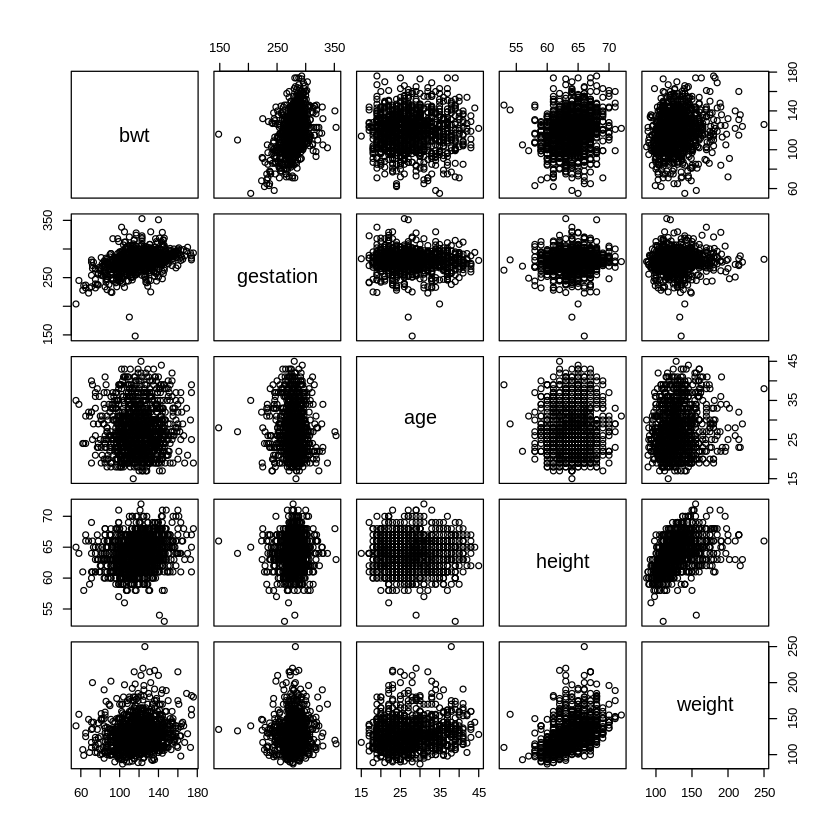

In [ ]:
babies4covclean<-babies4cov[(babies4cov$weight<999 & babies4cov$gestation<999 & babies4cov$height<99 & babies4cov$age< 99), ]
head(babies4covclean)
cov(babies4covclean)
cor(babies4covclean)
pairs(babies4covclean)

In [ ]:
babiesclean<-babies[(babies$weight<999 & babies$gestation<999 & babies$height<99 & babies$age< 99), ]

